In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [84]:
hydrants = pd.read_csv("hydrant_database.csv")
hydrants


,Hydrant,Latitude,Longitude,Capacity_L_min,Available,Capacity_source,Public_hydrant_object_id,Model_type,Location_source
0,H0001,55.655160,12.596182,1100,True,simulated_from_model_type,1,"unset, 80 mm",6100_Brandhaner__Koebenhavn
1,H0002,55.656111,12.596540,400,True,simulated_from_model_type,2,"unset, 80 mm",6100_Brandhaner__Koebenhavn
2,H0003,55.657671,12.597123,900,True,simulated_from_model_type,3,"unset, 80 mm",6100_Brandhaner__Koebenhavn
3,H0004,55.626594,12.532930,1600,True,simulated_from_model_type,4,"KV 1916, 100 mm",6100_Brandhaner__Koebenhavn
4,H0005,55.629802,12.537386,1600,True,simulated_from_model_type,5,"KV 1916, 100 mm",6100_Brandhaner__Koebenhavn
...,...,...,...,...,...,...,...,...,...
995,H0996,55.640751,12.599269,400,True,simulated_from_model_type,996,"unset, unset",6100_Brandhaner__Koebenhavn
996,H0997,55.638674,12.599940,600,True,simulated_from_model_type,997,"unset, unset",6100_Brandhaner__Koebenhavn
997,H0998,55.638730,12.597159,1100,True,simulated_from_model_type,998,"unset, unset",6100_Brandhaner__Koebenhavn
998,H0999,55.637998,12.597554,900,True,simulated_from_model_type,999,"unset, unset",6100_Brandhaner__Koebenhavn


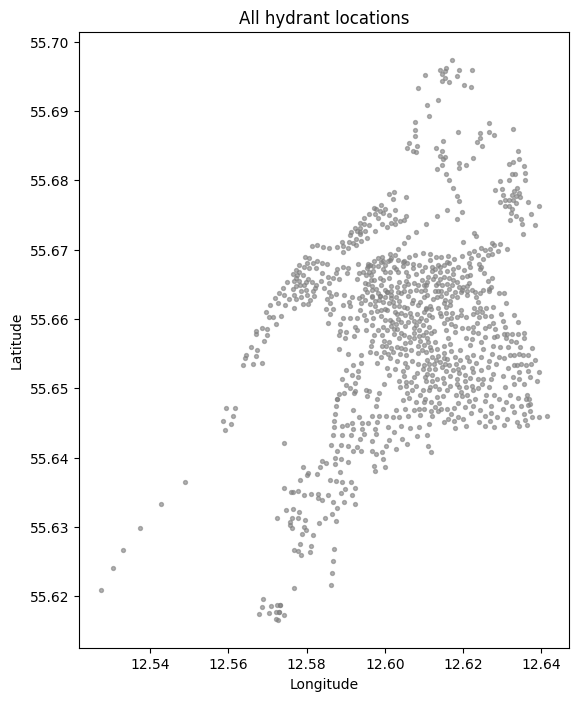

In [85]:
# Scatter plot of all hydrant locations
plt.figure(figsize=(10, 8))
plt.scatter(hydrants["Longitude"], hydrants["Latitude"], s=8, c="gray", alpha=0.6)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("All hydrant locations")
plt.gca().set_aspect(1.0 / np.cos(np.radians(hydrants["Latitude"].mean())))
plt.show()


In [86]:
def manhattan_distance(lat1, lon1, lat2, lon2):
    """Manhattan (city-block) distance in meters using an equirectangular projection."""
    lat_m_per_deg = 111320.0
    lon_m_per_deg = 111320.0 * np.cos(np.radians((lat1 + lat2) / 2.0))
    return abs((lat1 - lat2) * lat_m_per_deg) + abs((lon1 - lon2) * lon_m_per_deg)


In [87]:
def nearby_hydrants(fire_lat, fire_lon, radius_m, hydrants_df, max_results=None):
    """Return hydrants within `radius_m` (Manhattan) of the fire, sorted by distance.

    Returns a DataFrame indexed by Hydrant with columns Distance_m and Capacity_L_min.
    """
    avail = hydrants_df[hydrants_df["Available"] == True].copy()

    lat_m_per_deg = 111320.0
    lon_m_per_deg = 111320.0 * np.cos(np.radians((fire_lat + avail["Latitude"]) / 2.0))

    dx = (avail["Longitude"] - fire_lon) * lon_m_per_deg
    dy = (avail["Latitude"] - fire_lat) * lat_m_per_deg
    avail["Distance_m"] = np.abs(dx) + np.abs(dy)

    within = avail[avail["Distance_m"] <= radius_m].sort_values("Distance_m")
    if max_results is not None:
        within = within.head(max_results)

    if "Hydrant" in within.columns:
        within = within.set_index("Hydrant")
    return within[["Distance_m", "Capacity_L_min"]]


In [88]:
def plot_nearby(fire_lat, fire_lon, radius_m, hydrants_df, nearby_df):
    """Plot all hydrants, the nearby hydrants, the fire, and the radius circle."""
    nearby = nearby_df.copy()
    if "Hydrant" in hydrants_df.columns:
        locs = hydrants_df.set_index("Hydrant")
    else:
        locs = hydrants_df
    nearby["Latitude"] = locs.loc[nearby.index, "Latitude"]
    nearby["Longitude"] = locs.loc[nearby.index, "Longitude"]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(hydrants_df["Longitude"], hydrants_df["Latitude"], s=8, c="gray", alpha=0.5, label="All hydrants")
    ax.scatter(nearby["Longitude"], nearby["Latitude"], s=nearby["Capacity_L_min"] / 150, c="blue", alpha=0.7, label="Nearby hydrants")
    ax.scatter([fire_lon], [fire_lat], s=150, c="red", marker="*", label="Fire")

    lat_m_per_deg = 111320.0
    lon_m_per_deg = 111320.0 * np.cos(np.radians(fire_lat))
    diamond_x = [fire_lon + radius_m / lon_m_per_deg, fire_lon,
                 fire_lon - radius_m / lon_m_per_deg, fire_lon,
                 fire_lon + radius_m / lon_m_per_deg]
    diamond_y = [fire_lat, fire_lat + radius_m / lat_m_per_deg,
                 fire_lat, fire_lat - radius_m / lat_m_per_deg, fire_lat]
    ax.plot(diamond_x, diamond_y, color="red", linestyle="--", label=f"Radius {radius_m} m")

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Hydrants near the fire")
    ax.set_aspect(1.0 / np.cos(np.radians(fire_lat)))
    ax.legend()
    plt.show()
    return fig, ax


In [89]:
def pick_candidates(fire_lat, fire_lon, capacity_needed, hydrants_df,
                    safety_factor=1.5, radius_step=100):
    """Scan increasing radii and return the first one whose nearby hydrants
    cover `capacity_needed * safety_factor`.

    Returns (radius, near) or (None, None) if even all available hydrants
    cannot reach the target.
    """
    target = capacity_needed * safety_factor
    radius = 0
    while True:
        radius += radius_step
        near = nearby_hydrants(fire_lat, fire_lon, radius, hydrants_df)
        if near["Capacity_L_min"].sum() >= target:
            return radius, near
        n_available = (hydrants_df["Available"] == True).sum()
        if len(near) >= n_available:
            print(f"Warning: all {n_available} available hydrants total "
                  f"{near['Capacity_L_min'].sum()} L/min, less than target {target:.0f} L/min.")
            return None, None


In [90]:
def save_scenario(near, path="candidates.csv"):
    """Write candidate hydrants (index + distance + capacity) to a CSV."""
    near.reset_index().to_csv(path, index=False)


In [91]:
# Demo: a fire in a dense part of the city
fire_lat = 55.664178
fire_lon = 12.607972
capacity_needed = 4000

radius, near = pick_candidates(fire_lat, fire_lon, capacity_needed, hydrants)
print(f"Fire at ({fire_lat:.6f}, {fire_lon:.6f}) -> radius {radius} m")
save_scenario(near)
near


Fire at (55.664178, 12.607972) -> radius 200 m


,Distance_m,Capacity_L_min
Hydrant,,
H0479,0.000000,2700
H0484,94.622568,2100
H0596,112.676814,900
H0476,115.788840,1400
H0592,143.730618,1200
H0491,148.311431,1000
H0475,197.887328,1800


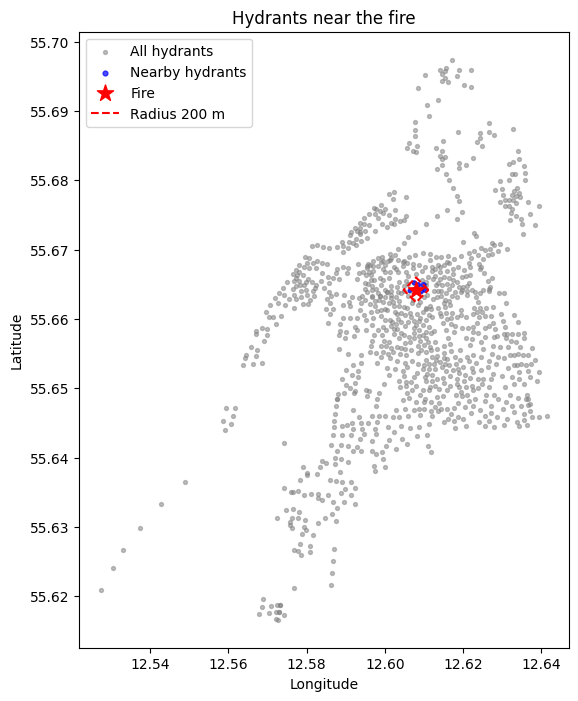

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Hydrants near the fire'}, xlabel='Longitude', ylabel='Latitude'>)

In [92]:
plot_nearby(fire_lat, fire_lon, radius, hydrants, near)
